# Training ResNet50 Transfer Learning per FER-2013

Questo notebook addestra un modello ResNet50 pre-addestrato su ImageNet per il riconoscimento delle emozioni facciali nel dataset FER-2013.

Usa gli stessi split del progetto:

- `data/processed/train`
- `data/processed/validation`
- `data/original/test`

Ogni run viene salvata in `experiments/<timestamp>_ResNet50_transfer/`.
Gli output per documentazione e confronto vengono esportati in `results/`.

Nota: ResNet50 usa immagini RGB. Le immagini FER-2013 sono grayscale, quindi vengono caricate come RGB duplicando il canale e ridimensionate a 96x96.

## Setup

In [9]:
from pathlib import Path
from time import perf_counter
from datetime import datetime
from contextlib import contextmanager
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from keras import Model
from keras.models import load_model
from keras.layers import Input, Dense, Dropout, GlobalAveragePooling2D, BatchNormalization
from keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau, Callback
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import AUC
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.utils.class_weight import compute_class_weight


def log_step(message):
    now = datetime.now().strftime("%H:%M:%S")
    print(f"[{now}] {message}", flush=True)


@contextmanager
def timed_step(name):
    start_time = perf_counter()
    log_step(f"INIZIO - {name}")
    try:
        yield
    finally:
        elapsed = perf_counter() - start_time
        log_step(f"FINE - {name} ({elapsed:.1f}s)")


def count_images_by_class(root_dir, extension=".jpg"):
    root_dir = Path(root_dir)
    counts = {}
    if not root_dir.exists():
        return counts

    for class_dir in sorted([p for p in root_dir.iterdir() if p.is_dir()]):
        counts[class_dir.name] = len(list(class_dir.glob(f"*{extension}")))

    return counts


def history_to_frame(history, phase, start_epoch=0):
    frame = pd.DataFrame(history.history)
    frame.insert(0, "phase", phase)
    frame.insert(1, "epoch", np.arange(start_epoch, start_epoch + len(frame)))
    return frame


class EpochTimingLogger(Callback):
    def on_train_begin(self, logs=None):
        self.training_start = perf_counter()
        log_step("Training phase avviata")

    def on_epoch_begin(self, epoch, logs=None):
        self.epoch_start = perf_counter()
        log_step(f"Epoca {epoch + 1} avviata")

    def on_epoch_end(self, epoch, logs=None):
        elapsed = perf_counter() - self.epoch_start
        logs = logs or {}
        metrics = []
        for key in ["loss", "accuracy", "auc", "val_loss", "val_accuracy", "val_auc"]:
            if key in logs:
                metrics.append(f"{key}={logs[key]:.4f}")

        lr = float(tf.keras.backend.get_value(self.model.optimizer.learning_rate))
        metrics.append(f"lr={lr:.2e}")
        log_step(f"Epoca {epoch + 1} completata in {elapsed:.1f}s - " + " | ".join(metrics))

    def on_train_end(self, logs=None):
        elapsed = perf_counter() - self.training_start
        log_step(f"Training phase terminata in {elapsed / 60:.1f} minuti")


SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

log_step(f"TensorFlow: {tf.__version__}")
log_step(f"GPU disponibili: {tf.config.list_physical_devices('GPU')}")

[13:39:30] TensorFlow: 2.20.0
[13:39:30] GPU disponibili: []


## Configurazione percorsi

In [ ]:
with timed_step("Configurazione percorsi ResNet50"):
    current_dir = Path.cwd()
    project_root = current_dir if (current_dir / "data").exists() else current_dir.parent

    train_dir = project_root / "data" / "processed" / "train"
    validation_dir = project_root / "data" / "processed" / "validation"
    test_dir = project_root / "data" / "original" / "test"

    experiments_root = project_root / "experiments"
    results_root = project_root / "results"
    results_figures_dir = results_root / "figures"
    results_tables_dir = results_root / "tables"
    results_predictions_dir = results_root / "predictions"

    for output_dir in [experiments_root, results_figures_dir, results_tables_dir, results_predictions_dir]:
        output_dir.mkdir(parents=True, exist_ok=True)

    IMG_HEIGHT = 224
    IMG_WIDTH = 224
    BATCH_SIZE = 32
    FEATURE_EPOCHS = 15
    FINE_TUNE_EPOCHS = 20
    FINE_TUNE_LAST_LAYERS = 30
    FEATURE_LEARNING_RATE = 1e-3
    FINE_TUNE_LEARNING_RATE = 1e-5

    if not train_dir.exists():
        raise FileNotFoundError(f"Cartella training preprocessata non trovata: {train_dir}. Esegui prima notebooks/Preprocessing.ipynb.")
    if not validation_dir.exists():
        raise FileNotFoundError(f"Cartella validation preprocessata non trovata: {validation_dir}. Esegui prima notebooks/Preprocessing.ipynb.")
    if not test_dir.exists():
        raise FileNotFoundError(f"Cartella test non trovata: {test_dir}")

    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    model_name = "ResNet50_transfer"
    experiment_dir = experiments_root / f"{timestamp}_{model_name}"
    experiment_dir.mkdir(parents=True, exist_ok=True)

    best_model_path = experiment_dir / "model.keras"
    feature_history_path = experiment_dir / "feature_history.csv"
    fine_tuning_history_path = experiment_dir / "fine_tuning_history.csv"
    training_history_path = experiment_dir / "training_history.csv"
    log_output_path = experiment_dir / "training_log.txt"
    config_path = experiment_dir / "config.json"
    test_results_path = experiment_dir / "test_results.txt"

    log_step(f"Project root: {project_root}")
    log_step(f"Training directory: {train_dir}")
    log_step(f"Validation directory: {validation_dir}")
    log_step(f"Test directory: {test_dir}")
    log_step(f"Experiment directory: {experiment_dir}")
    log_step(f"Input size: {IMG_HEIGHT}x{IMG_WIDTH} RGB")
    log_step(f"Batch size: {BATCH_SIZE}")

[22:32:34] INIZIO - Configurazione percorsi ResNet50
[22:32:34] Project root: c:\Users\Matteo\Documents\GitHub\ProgettoDL_FaceFERward
[22:32:34] Training directory: c:\Users\Matteo\Documents\GitHub\ProgettoDL_FaceFERward\data\processed\train
[22:32:34] Validation directory: c:\Users\Matteo\Documents\GitHub\ProgettoDL_FaceFERward\data\processed\validation
[22:32:34] Test directory: c:\Users\Matteo\Documents\GitHub\ProgettoDL_FaceFERward\data\original\test
[22:32:34] Experiment directory: c:\Users\Matteo\Documents\GitHub\ProgettoDL_FaceFERward\experiments\20260630_223234_ResNet50_transfer
[22:32:34] Input size: 226x226 RGB
[22:32:34] Batch size: 32
[22:32:34] FINE - Configurazione percorsi ResNet50 (0.0s)


## Generatori e class weights

In [ ]:
from tensorflow.keras.applications.resnet50 import preprocess_input

with timed_step("Creazione generatori ResNet50 e class weights"):
    train_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)
    validation_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)
    test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

    log_step("Creo train_generator RGB con augmentation online")
    train_generator = train_datagen.flow_from_directory(
        train_dir,
        target_size=(IMG_HEIGHT, IMG_WIDTH),
        batch_size=BATCH_SIZE,
        color_mode="rgb",
        class_mode="categorical",
        seed=SEED,
    )

    log_step("Creo validation_generator RGB senza augmentation")
    validation_generator = validation_datagen.flow_from_directory(
        validation_dir,
        target_size=(IMG_HEIGHT, IMG_WIDTH),
        batch_size=BATCH_SIZE,
        color_mode="rgb",
        class_mode="categorical",
        seed=SEED,
        shuffle=False,
    )

    log_step("Creo test_generator RGB senza augmentation")
    test_generator = test_datagen.flow_from_directory(
        test_dir,
        target_size=(IMG_HEIGHT, IMG_WIDTH),
        batch_size=BATCH_SIZE,
        color_mode="rgb",
        class_mode="categorical",
        shuffle=False,
    )

    class_indices = train_generator.class_indices
    emotion_labels = {v: k for k, v in class_indices.items()}
    target_names = [emotion_labels[i] for i in range(len(emotion_labels))]

    class_weights_array = compute_class_weight(
        class_weight="balanced",
        classes=np.unique(train_generator.classes),
        y=train_generator.classes,
    )
    class_weights = dict(enumerate(class_weights_array))

    train_counts = count_images_by_class(train_dir)
    validation_counts = count_images_by_class(validation_dir)
    test_counts = count_images_by_class(test_dir)

    log_step(f"Classi: {class_indices}")
    log_step(f"Training samples: {train_generator.samples} ({len(train_generator)} batch/epoca)")
    log_step(f"Validation samples: {validation_generator.samples} ({len(validation_generator)} batch)")
    log_step(f"Test samples: {test_generator.samples} ({len(test_generator)} batch)")

    for class_name in sorted(set(train_counts) | set(validation_counts) | set(test_counts)):
        log_step(
            f"{class_name}: train={train_counts.get(class_name, 0)}, "
            f"validation={validation_counts.get(class_name, 0)}, "
            f"test={test_counts.get(class_name, 0)}"
        )

    log_step(f"Class weights: {class_weights}")

[13:57:27] INIZIO - Creazione generatori ResNet50 e class weights
[13:57:27] Creo train_generator RGB con augmentation online
Found 32155 images belonging to 7 classes.
[13:57:28] Creo validation_generator RGB senza augmentation
Found 5741 images belonging to 7 classes.
[13:57:28] Creo test_generator RGB senza augmentation
Found 7178 images belonging to 7 classes.
[13:57:28] Classi: {'angry': 0, 'disgust': 1, 'fear': 2, 'happy': 3, 'neutral': 4, 'sad': 5, 'surprise': 6}
[13:57:28] Training samples: 32155 (1005 batch/epoca)
[13:57:28] Validation samples: 5741 (180 batch)
[13:57:28] Test samples: 7178 (225 batch)
[13:57:28] angry: train=4507, validation=799, test=958
[13:57:28] disgust: train=477, validation=87, test=111
[13:57:28] fear: train=4588, validation=819, test=1024
[13:57:28] happy: train=8062, validation=1443, test=1774
[13:57:28] neutral: train=5560, validation=993, test=1233
[13:57:28] sad: train=5407, validation=966, test=1247
[13:57:28] surprise: train=3554, validation=634

## Modello ResNet50

In [16]:
with timed_step("Costruzione ResNet50 transfer learning"):
    base_model = ResNet50(
        weights="imagenet",
        include_top=False,
        input_shape=(IMG_HEIGHT, IMG_WIDTH, 3),
    )
    base_model.trainable = False

    inputs = Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3))
    
    x = base_model(inputs, training=False)
    
    x = GlobalAveragePooling2D()(x)
    x = Dropout(0.30)(x)
    
    outputs = Dense(len(class_indices), activation="softmax")(x)
    
    model = Model(inputs, outputs, name="resnet50_transfer_fer2013")

    model.compile(
        optimizer=Adam(learning_rate=FEATURE_LEARNING_RATE),
        loss="categorical_crossentropy",
        metrics=["accuracy", AUC(name="auc")],
    )

    total_params = int(model.count_params())
    trainable_params = int(sum(np.prod(v.shape) for v in model.trainable_weights))
    non_trainable_params = total_params - trainable_params

    log_step(f"Parametri totali: {total_params:,}")
    log_step(f"Parametri trainable feature extraction: {trainable_params:,}")
    log_step(f"Parametri non trainable: {non_trainable_params:,}")
    model.summary()

[13:57:31] INIZIO - Costruzione ResNet50 transfer learning
[13:57:32] Parametri totali: 23,602,055
[13:57:32] Parametri trainable feature extraction: 14,343
[13:57:32] Parametri non trainable: 23,587,712


Model: "resnet50_transfer_fer2013"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 226, 226, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 8, 8, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 7)              │        14,343 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,602,055 (90.03 MB)

 Trainable params: 14,343 (56.03 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

[13:57:32] FINE - Costruzione ResNet50 transfer learning (0.7s)


### Fase 1 - Feature extraction

In [17]:
feature_callbacks = [
    EpochTimingLogger(),
    EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-6),
    ModelCheckpoint(str(best_model_path), monitor="val_loss", save_best_only=True),
]

with timed_step("Training ResNet50 - feature extraction"):
    feature_start = perf_counter()
    feature_history = model.fit(
        train_generator,
        epochs=FEATURE_EPOCHS,
        validation_data=validation_generator,
        callbacks=feature_callbacks,
        class_weight=class_weights,
        verbose=1,
    )
    feature_train_time_seconds = perf_counter() - feature_start

feature_frame = history_to_frame(feature_history, "feature_extraction", start_epoch=0)
feature_frame.to_csv(feature_history_path, index=False)
log_step(f"Feature extraction history salvata in: {feature_history_path}")

[13:57:35] INIZIO - Training ResNet50 - feature extraction
[13:57:35] Training phase avviata
[13:57:35] Epoca 1 avviata
Epoch 1/15
1005/1005 ━━━━━━━━━━━━━━━━━━━━ 0s 741ms/step - accuracy: 0.2447 - auc: 0.6323 - loss: 2.0393[14:12:16] Epoca 1 completata in 880.4s - loss=1.9115 | accuracy=0.2836 | auc=0.6732 | val_loss=1.5912 | val_accuracy=0.3952 | val_auc=0.7700 | lr=1.00e-03
1005/1005 ━━━━━━━━━━━━━━━━━━━━ 881s 873ms/step - accuracy: 0.2836 - auc: 0.6732 - loss: 1.9115 - val_accuracy: 0.3952 - val_auc: 0.7700 - val_loss: 1.5912 - learning_rate: 0.0010
[14:12:16] Epoca 2 avviata
Epoch 2/15
1005/1005 ━━━━━━━━━━━━━━━━━━━━ 0s 745ms/step - accuracy: 0.3223 - auc: 0.7104 - loss: 1.8109[14:26:55] Epoca 2 completata in 879.0s - loss=1.7692 | accuracy=0.3321 | auc=0.7186 | val_loss=1.4433 | val_accuracy=0.4574 | val_auc=0.8162 | lr=1.00e-03
1005/1005 ━━━━━━━━━━━━━━━━━━━━ 880s 875ms/step - accuracy: 0.3321 - auc: 0.7186 - loss: 1.7692 - val_accuracy: 0.4574 - val_auc: 0.8162 - val_loss: 1.4433 -

### Fase 2 - Fine tuning

In [18]:
with timed_step("Configurazione fine tuning ResNet50"):
    base_model.trainable = True
    fine_tune_at = max(0, len(base_model.layers) - FINE_TUNE_LAST_LAYERS)

    for layer in base_model.layers[:fine_tune_at]:
        layer.trainable = False

    for layer in base_model.layers:
        if isinstance(layer, BatchNormalization):
            layer.trainable = False

    model.compile(
        optimizer=Adam(learning_rate=FINE_TUNE_LEARNING_RATE),
        loss="categorical_crossentropy",
        metrics=["accuracy", AUC(name="auc")],
    )

    total_params = int(model.count_params())
    fine_tune_trainable_params = int(sum(np.prod(v.shape) for v in model.trainable_weights))
    fine_tune_non_trainable_params = total_params - fine_tune_trainable_params

    log_step(f"Layer totali ResNet50: {len(base_model.layers)}")
    log_step(f"Fine tuning dagli ultimi {FINE_TUNE_LAST_LAYERS} layer circa, indice di taglio: {fine_tune_at}")
    log_step(f"Parametri trainable fine tuning: {fine_tune_trainable_params:,}")
    log_step(f"Parametri non trainable fine tuning: {fine_tune_non_trainable_params:,}")


fine_tune_callbacks = [
    EpochTimingLogger(),
    EarlyStopping(monitor="val_loss", patience=6, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-7),
    ModelCheckpoint(str(best_model_path), monitor="val_loss", save_best_only=True),
]

with timed_step("Training ResNet50 - fine tuning"):
    fine_tune_start = perf_counter()
    fine_tune_history = model.fit(
        train_generator,
        epochs=FINE_TUNE_EPOCHS,
        validation_data=validation_generator,
        callbacks=fine_tune_callbacks,
        class_weight=class_weights,
        verbose=1,
    )
    fine_tune_train_time_seconds = perf_counter() - fine_tune_start

fine_tune_frame = history_to_frame(
    fine_tune_history,
    "fine_tuning",
    start_epoch=len(feature_frame),
)
fine_tune_frame.to_csv(fine_tuning_history_path, index=False)

training_history = pd.concat([feature_frame, fine_tune_frame], ignore_index=True)
training_history.to_csv(training_history_path, index=False)

best_val_loss = float(training_history["val_loss"].min())
best_epoch = int(training_history["val_loss"].idxmin()) + 1
best_val_accuracy = float(training_history["val_accuracy"].max())
best_val_accuracy_epoch = int(training_history["val_accuracy"].idxmax()) + 1
best_val_auc = float(training_history["val_auc"].max())
best_val_auc_epoch = int(training_history["val_auc"].idxmax()) + 1

log_step(f"Training history completa salvata in: {training_history_path}")
log_step(f"Migliore val_loss: {best_val_loss:.4f} all'epoca {best_epoch}")
log_step(f"Migliore val_accuracy: {best_val_accuracy:.4f} all'epoca {best_val_accuracy_epoch}")
log_step(f"Migliore val_auc: {best_val_auc:.4f} all'epoca {best_val_auc_epoch}")

[15:54:48] INIZIO - Configurazione fine tuning ResNet50
[15:54:48] Layer totali ResNet50: 175
[15:54:48] Fine tuning dagli ultimi 30 layer circa, indice di taglio: 145
[15:54:48] Parametri trainable fine tuning: 14,443,015
[15:54:48] Parametri non trainable fine tuning: 9,159,040
[15:54:48] FINE - Configurazione fine tuning ResNet50 (0.0s)
[15:54:48] INIZIO - Training ResNet50 - fine tuning
[15:54:49] Training phase avviata
[15:54:49] Epoca 1 avviata
Epoch 1/20
1005/1005 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.3756 - auc: 0.7566 - loss: 1.6293[16:14:04] Epoca 1 completata in 1161.8s - loss=1.5654 | accuracy=0.3950 | auc=0.7735 | val_loss=1.3810 | val_accuracy=0.4868 | val_auc=0.8354 | lr=1.00e-05
1005/1005 ━━━━━━━━━━━━━━━━━━━━ 1157s 1s/step - accuracy: 0.3950 - auc: 0.7735 - loss: 1.5654 - val_accuracy: 0.4868 - val_auc: 0.8354 - val_loss: 1.3810 - learning_rate: 1.0000e-05
[16:14:05] Epoca 2 avviata
Epoch 2/20
1005/1005 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.4319 - auc: 0

### Curve di apprendimento

[22:26:15] INIZIO - Creazione curve ResNet50
[22:26:16] Curve di apprendimento salvate in: c:\Users\Matteo\Documents\GitHub\ProgettoDL_FaceFERward\results\figures\20260630_135725_ResNet50_transfer_training_curves.png


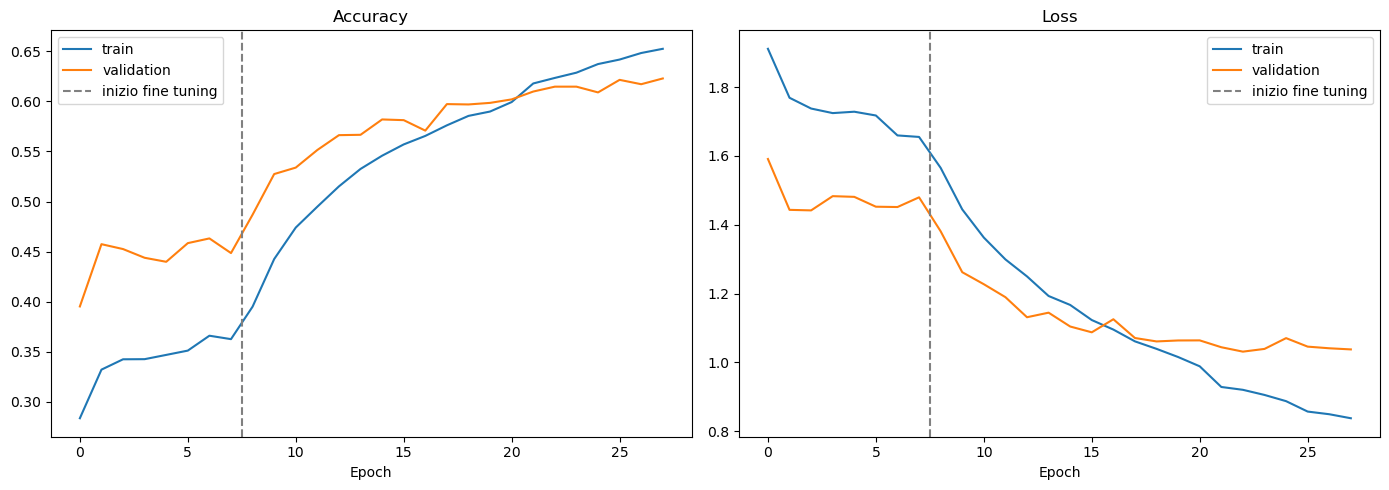

[22:26:16] FINE - Creazione curve ResNet50 (0.5s)


In [19]:
with timed_step("Creazione curve ResNet50"):
    fig = plt.figure(figsize=(14, 5))

    plt.subplot(1, 2, 1)
    plt.plot(training_history["epoch"], training_history["accuracy"], label="train")
    plt.plot(training_history["epoch"], training_history["val_accuracy"], label="validation")
    plt.axvline(len(feature_frame) - 0.5, color="gray", linestyle="--", label="inizio fine tuning")
    plt.title("Accuracy")
    plt.xlabel("Epoch")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(training_history["epoch"], training_history["loss"], label="train")
    plt.plot(training_history["epoch"], training_history["val_loss"], label="validation")
    plt.axvline(len(feature_frame) - 0.5, color="gray", linestyle="--", label="inizio fine tuning")
    plt.title("Loss")
    plt.xlabel("Epoch")
    plt.legend()

    plt.tight_layout()

    curves_path = results_figures_dir / f"{experiment_dir.name}_training_curves.png"
    fig.savefig(curves_path, dpi=150, bbox_inches="tight")
    log_step(f"Curve di apprendimento salvate in: {curves_path}")

    plt.show()

## Valutazione finale sul test set

[22:26:37] INIZIO - Valutazione finale ResNet50 sul test set
[22:26:37] Carico il miglior modello salvato: c:\Users\Matteo\Documents\GitHub\ProgettoDL_FaceFERward\experiments\20260630_135725_ResNet50_transfer\model.keras
225/225 ━━━━━━━━━━━━━━━━━━━━ 175s 764ms/step - accuracy: 0.6193 - auc: 0.9094 - loss: 1.0510
[22:29:33] Test loss: 1.0510
[22:29:33] Test accuracy: 0.6193
[22:29:33] Test AUC: 0.9094
225/225 ━━━━━━━━━━━━━━━━━━━━ 181s 799ms/step
[22:32:34] Classification report
              precision    recall  f1-score   support

       angry       0.52      0.53      0.53       958
     disgust       0.55      0.59      0.57       111
        fear       0.49      0.33      0.40      1024
       happy       0.80      0.85      0.83      1774
     neutral       0.54      0.64      0.58      1233
         sad       0.50      0.51      0.51      1247
    surprise       0.76      0.72      0.74       831

    accuracy                           0.62      7178
   macro avg       0.59      0

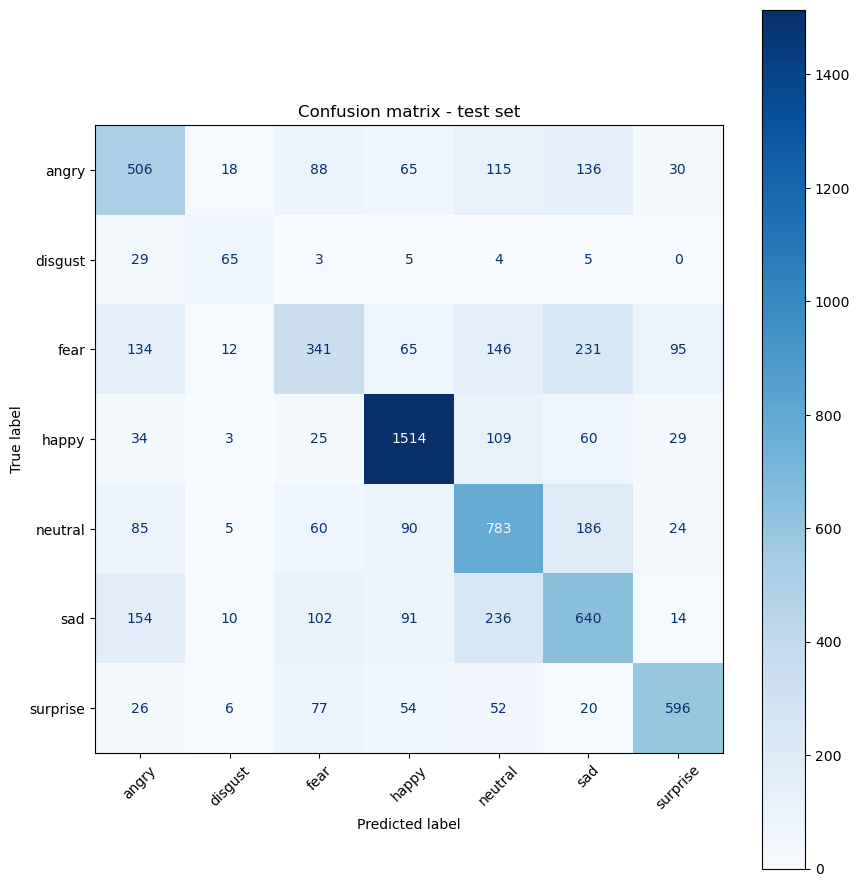

[22:32:34] Risultati del test salvati in: c:\Users\Matteo\Documents\GitHub\ProgettoDL_FaceFERward\experiments\20260630_135725_ResNet50_transfer\test_results.txt
[22:32:34] Config salvata in: c:\Users\Matteo\Documents\GitHub\ProgettoDL_FaceFERward\experiments\20260630_135725_ResNet50_transfer\config.json
[22:32:34] Classification report CSV salvato in: c:\Users\Matteo\Documents\GitHub\ProgettoDL_FaceFERward\results\tables\20260630_135725_ResNet50_transfer_classification_report.csv
[22:32:34] Confusion matrix CSV salvata in: c:\Users\Matteo\Documents\GitHub\ProgettoDL_FaceFERward\results\tables\20260630_135725_ResNet50_transfer_confusion_matrix.csv
[22:32:34] Predizioni test salvate in: c:\Users\Matteo\Documents\GitHub\ProgettoDL_FaceFERward\results\predictions\20260630_135725_ResNet50_transfer_test_predictions.csv
[22:32:34] Confusion matrix PNG salvata in: c:\Users\Matteo\Documents\GitHub\ProgettoDL_FaceFERward\results\figures\20260630_135725_ResNet50_transfer_confusion_matrix.png
[22:

In [20]:
with timed_step("Valutazione finale ResNet50 sul test set"):
    if best_model_path.exists():
        log_step(f"Carico il miglior modello salvato: {best_model_path}")
        model = load_model(best_model_path)

    evaluate_start = perf_counter()
    test_loss, test_accuracy, test_auc = model.evaluate(test_generator, verbose=1)
    evaluate_time_seconds = perf_counter() - evaluate_start

    log_step(f"Test loss: {test_loss:.4f}")
    log_step(f"Test accuracy: {test_accuracy:.4f}")
    log_step(f"Test AUC: {test_auc:.4f}")

    predict_start = perf_counter()
    y_true = test_generator.classes
    y_pred_proba = model.predict(test_generator, verbose=1)
    predict_time_seconds = perf_counter() - predict_start
    y_pred = np.argmax(y_pred_proba, axis=1)

    inference_time_ms_per_image = (predict_time_seconds / test_generator.samples) * 1000

    class_report = classification_report(y_true, y_pred, target_names=target_names)
    class_report_dict = classification_report(
        y_true,
        y_pred,
        target_names=target_names,
        output_dict=True,
    )
    conf_matrix = confusion_matrix(y_true, y_pred)

    log_step("Classification report")
    print(class_report)

    log_step("Confusion matrix")
    print(conf_matrix)

    with open(test_results_path, "w", encoding="utf-8") as f:
        f.write("=== VALUTAZIONE FINALE SUL TEST SET ===\n\n")
        f.write(f"Test Loss: {test_loss:.4f}\n")
        f.write(f"Test Accuracy: {test_accuracy:.4f}\n")
        f.write(f"Test AUC: {test_auc:.4f}\n")
        f.write(f"Macro F1: {class_report_dict['macro avg']['f1-score']:.4f}\n")
        f.write(f"Weighted F1: {class_report_dict['weighted avg']['f1-score']:.4f}\n")
        f.write(f"Inference time: {inference_time_ms_per_image:.4f} ms/image\n\n")
        f.write("=== CLASSIFICATION REPORT ===\n")
        f.write(class_report)
        f.write("\n=== CONFUSION MATRIX ===\n")
        f.write(np.array2string(conf_matrix))

    report_csv_path = results_tables_dir / f"{experiment_dir.name}_classification_report.csv"
    confusion_csv_path = results_tables_dir / f"{experiment_dir.name}_confusion_matrix.csv"
    predictions_csv_path = results_predictions_dir / f"{experiment_dir.name}_test_predictions.csv"
    confusion_fig_path = results_figures_dir / f"{experiment_dir.name}_confusion_matrix.png"

    pd.DataFrame(class_report_dict).transpose().to_csv(report_csv_path)
    pd.DataFrame(conf_matrix, index=target_names, columns=target_names).to_csv(confusion_csv_path)

    predictions_df = pd.DataFrame(
        {
            "filepath": test_generator.filepaths,
            "true_label": [target_names[i] for i in y_true],
            "predicted_label": [target_names[i] for i in y_pred],
        }
    )
    for class_index, class_name in enumerate(target_names):
        predictions_df[f"prob_{class_name}"] = y_pred_proba[:, class_index]
    predictions_df.to_csv(predictions_csv_path, index=False)

    disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=target_names)
    fig, ax = plt.subplots(figsize=(9, 9))
    disp.plot(ax=ax, cmap="Blues", xticks_rotation=45)
    plt.title("Confusion matrix - test set")
    plt.tight_layout()
    fig.savefig(confusion_fig_path, dpi=150, bbox_inches="tight")
    plt.show()

    model_size_mb = best_model_path.stat().st_size / (1024 * 1024) if best_model_path.exists() else 0.0
    total_train_time_seconds = feature_train_time_seconds + fine_tune_train_time_seconds

    config = {
        "model_name": model_name,
        "timestamp": timestamp,
        "pretrained_weights": "imagenet",
        "base_model": "ResNet50",
        "input_shape": [IMG_HEIGHT, IMG_WIDTH, 3],
        "batch_size": BATCH_SIZE,
        "feature_epochs": FEATURE_EPOCHS,
        "fine_tune_epochs": FINE_TUNE_EPOCHS,
        "fine_tune_last_layers": FINE_TUNE_LAST_LAYERS,
        "feature_learning_rate": FEATURE_LEARNING_RATE,
        "fine_tune_learning_rate": FINE_TUNE_LEARNING_RATE,
        "optimizer": "Adam",
        "loss": "categorical_crossentropy",
        "metrics": ["accuracy", "auc"],
        "class_weight": {str(k): float(v) for k, v in class_weights.items()},
        "train_dir": str(train_dir.relative_to(project_root)),
        "validation_dir": str(validation_dir.relative_to(project_root)),
        "test_dir": str(test_dir.relative_to(project_root)),
        "output_dir": str(experiment_dir.relative_to(project_root)),
        "total_params": int(model.count_params()),
        "feature_trainable_params": int(trainable_params),
        "fine_tune_trainable_params": int(fine_tune_trainable_params),
        "model_size_mb": float(model_size_mb),
        "feature_train_time_seconds": float(feature_train_time_seconds),
        "fine_tune_train_time_seconds": float(fine_tune_train_time_seconds),
        "total_train_time_seconds": float(total_train_time_seconds),
        "evaluate_time_seconds": float(evaluate_time_seconds),
        "predict_time_seconds": float(predict_time_seconds),
        "inference_time_ms_per_image": float(inference_time_ms_per_image),
        "test_loss": float(test_loss),
        "test_accuracy": float(test_accuracy),
        "test_auc": float(test_auc),
        "macro_f1": float(class_report_dict["macro avg"]["f1-score"]),
        "weighted_f1": float(class_report_dict["weighted avg"]["f1-score"]),
        "best_val_loss": float(best_val_loss),
        "best_val_loss_epoch": int(best_epoch),
        "best_val_accuracy": float(best_val_accuracy),
        "best_val_accuracy_epoch": int(best_val_accuracy_epoch),
        "best_val_auc": float(best_val_auc),
        "best_val_auc_epoch": int(best_val_auc_epoch),
    }

    with open(config_path, "w", encoding="utf-8") as f:
        json.dump(config, f, indent=2)

    with open(log_output_path, "w", encoding="utf-8") as f:
        f.write(f"Modello: {model_name}\n")
        f.write(f"Data: {timestamp}\n")
        f.write(f"Base model: ResNet50 pretrained on ImageNet\n")
        f.write(f"Migliore val_loss: {best_val_loss:.4f} all'epoca {best_epoch}\n")
        f.write(f"Test accuracy: {test_accuracy:.4f}\n")
        f.write(f"Test AUC: {test_auc:.4f}\n")
        f.write(f"Macro F1: {class_report_dict['macro avg']['f1-score']:.4f}\n")
        f.write(f"Weighted F1: {class_report_dict['weighted avg']['f1-score']:.4f}\n")
        f.write(f"Training totale: {total_train_time_seconds / 60:.1f} minuti\n")
        f.write(f"Inference time: {inference_time_ms_per_image:.4f} ms/image\n")

    comparison_path = results_tables_dir / "models_comparison.csv"
    comparison_row = {
        "experiment_name": experiment_dir.name,
        "model_name": model_name,
        "base_model": "ResNet50",
        "pretrained_weights": "imagenet",
        "input_size": f"{IMG_HEIGHT}x{IMG_WIDTH}x3",
        "test_accuracy": float(test_accuracy),
        "macro_f1": float(class_report_dict["macro avg"]["f1-score"]),
        "weighted_f1": float(class_report_dict["weighted avg"]["f1-score"]),
        "test_auc": float(test_auc),
        "num_params": int(model.count_params()),
        "model_size_mb": float(model_size_mb),
        "train_time_seconds": float(total_train_time_seconds),
        "inference_time_ms_per_image": float(inference_time_ms_per_image),
        "experiment_dir": str(experiment_dir.relative_to(project_root)),
    }

    if comparison_path.exists():
        comparison_df = pd.read_csv(comparison_path)
        comparison_df = comparison_df[comparison_df["experiment_name"] != experiment_dir.name]
        comparison_df = pd.concat([comparison_df, pd.DataFrame([comparison_row])], ignore_index=True)
    else:
        comparison_df = pd.DataFrame([comparison_row])
    comparison_df.to_csv(comparison_path, index=False)

    log_step(f"Risultati del test salvati in: {test_results_path}")
    log_step(f"Config salvata in: {config_path}")
    log_step(f"Classification report CSV salvato in: {report_csv_path}")
    log_step(f"Confusion matrix CSV salvata in: {confusion_csv_path}")
    log_step(f"Predizioni test salvate in: {predictions_csv_path}")
    log_step(f"Confusion matrix PNG salvata in: {confusion_fig_path}")
    log_step(f"Tabella confronto modelli aggiornata in: {comparison_path}")

## Note per il confronto

Questa run serve per confrontare la CNN custom con un modello pre-addestrato.

Per la presentazione e il README usare:

- `experiments/<run>/{config.json, model.keras, training_history.csv, training_log.txt, test_results.txt}`
- `results/tables/models_comparison.csv`
- `results/figures/<run>_training_curves.png`
- `results/figures/<run>_confusion_matrix.png`
- `results/predictions/<run>_test_predictions.csv`